# Stochastic Position Sampling

Visualizes the `stochastic` position sampling strategy (3-way split):
1. **20%** — last k contiguous positions, k ~ Uniform{1,...,5}
2. **50%** — sentence boundary (`.`) positions + last position; fallback to end-skewed if unavailable
3. **30%** — end-skewed random: k ~ Uniform{1, max_k}, Gumbel-top-k with weights w_i = ((i+0.5)/K)^(β-1) + floor (floor≈0.1 ensures ~5% mass in first decile)

**Eval-time** (deterministic): first token + sentence boundaries + last 5 contiguous tokens.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import random, math
import yaml
import numpy as np
import matplotlib.pyplot as plt

from cot_utils import sample_poisson_positions_tagged, sentence_boundaries_plus_last5, END_CONCENTRATION, END_WEIGHT_FLOOR

with open('../configs/train.yaml') as f:
    _cfg = yaml.safe_load(f)
MAX_K = _cfg['activations']['stochastic_max_k']

print(f"MAX_K = {MAX_K},  END_CONCENTRATION = {END_CONCENTRATION:.3f},  END_WEIGHT_FLOOR = {END_WEIGHT_FLOOR}")
print("Scheme: 20% last-1-5 | 50% sentence boundaries | 30% end-skewed random")
print("Eval:   first token + sentence boundaries + last 5 contiguous tokens")

MAX_K = 100,  END_CONCENTRATION = 11.427,  END_WEIGHT_FLOOR = 0.1
Scheme: 20% last-1-5 | 50% sentence boundaries | 30% end-skewed random
Eval:   first token + sentence boundaries + last 5 contiguous tokens


## 1. Bucket Identification

Verify the 20/50/30 split by drawing from the real `sample_poisson_positions_tagged`.

In [2]:
K = 200
base_positions = list(range(0, K * 5, 5))
rng_ref = random.Random(0)
period_positions = sorted(p for p in base_positions if rng_ref.random() < 0.05)  # ~1 per 100 tok

COLORS = {"last_k": "C0", "sentence": "C2", "end_skewed": "C1", "sentence_fallback": "C4"}
LABELS = {"last_k": "20% last-1-5", "sentence": "50% sentence boundaries", "end_skewed": "30% end-skewed", "all": "Overall"}

n_samples = 10_000
from collections import Counter
buckets = Counter()
rng = random.Random(42)
for _ in range(n_samples):
    _, b = sample_poisson_positions_tagged(base_positions, rng=rng, max_k=MAX_K, period_positions=period_positions)
    buckets[b] += 1

print("Bucket distribution:")
for b, c in sorted(buckets.items()):
    print(f"  {b:20s}: {c:5d} / {n_samples} = {c/n_samples:.1%}")

Bucket distribution:
  end_skewed          :  2972 / 10000 = 29.7%
  last_k              :  1997 / 10000 = 20.0%
  sentence            :  5031 / 10000 = 50.3%


## 2. Position Distribution Per Bucket

Where in the CoT does each bucket place its tokens?

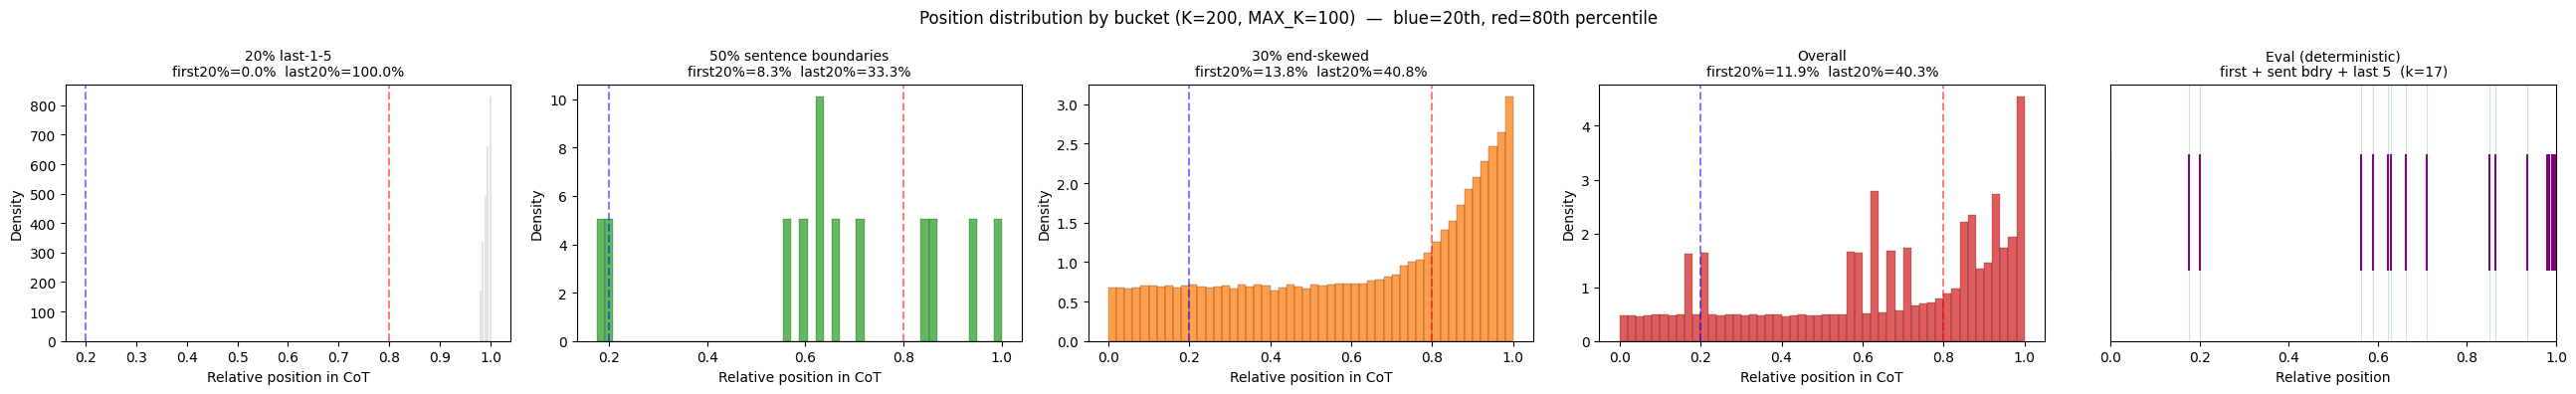

In [3]:
n_samples = 5_000
rng = random.Random(42)
data = {k: [] for k in ["last_k", "sentence", "end_skewed", "all"]}

for _ in range(n_samples):
    positions, bucket = sample_poisson_positions_tagged(base_positions, rng=rng, max_k=MAX_K, period_positions=period_positions)
    rel = [p / base_positions[-1] for p in positions]
    data.setdefault(bucket, []).extend(rel)
    data["all"].extend(rel)

eval_pos = sentence_boundaries_plus_last5(base_positions, period_positions)
eval_rel = [p / base_positions[-1] for p in eval_pos]

fig, axes = plt.subplots(1, 5, figsize=(26, 4), sharey=False)
for ax, key in zip(axes[:4], ["last_k", "sentence", "end_skewed", "all"]):
    vals = np.array(data.get(key, []))
    if len(vals) == 0:
        ax.set_title(f'{LABELS[key]}\n(no data)'); continue
    tail = (vals > 0.8).mean()
    head = (vals < 0.2).mean()
    ax.hist(vals, bins=50, density=True, alpha=0.75, color=COLORS.get(key, "C3"), edgecolor='black', linewidth=0.2)
    ax.axvline(0.8, color='red', linestyle='--', alpha=0.5)
    ax.axvline(0.2, color='blue', linestyle='--', alpha=0.5)
    ax.set_title(f'{LABELS[key]}\nfirst20%={head:.1%}  last20%={tail:.1%}', fontsize=10)
    ax.set_xlabel('Relative position in CoT')
    ax.set_ylabel('Density')

ax = axes[4]
ax.eventplot([eval_rel], lineoffsets=0.5, linelengths=0.8, colors='purple')
for sp in [p / base_positions[-1] for p in period_positions]:
    ax.axvline(sp, color='green', alpha=0.2, linewidth=0.8)
ax.set_xlim(0, 1); ax.set_yticks([])
ax.set_title(f'Eval (deterministic)\nfirst + sent bdry + last 5  (k={len(eval_pos)})', fontsize=10)
ax.set_xlabel('Relative position')

fig.suptitle(f'Position distribution by bucket (K={K}, MAX_K={MAX_K})  —  blue=20th, red=80th percentile', fontsize=12)
plt.tight_layout()
plt.show()

## 3. k Distribution Per Bucket

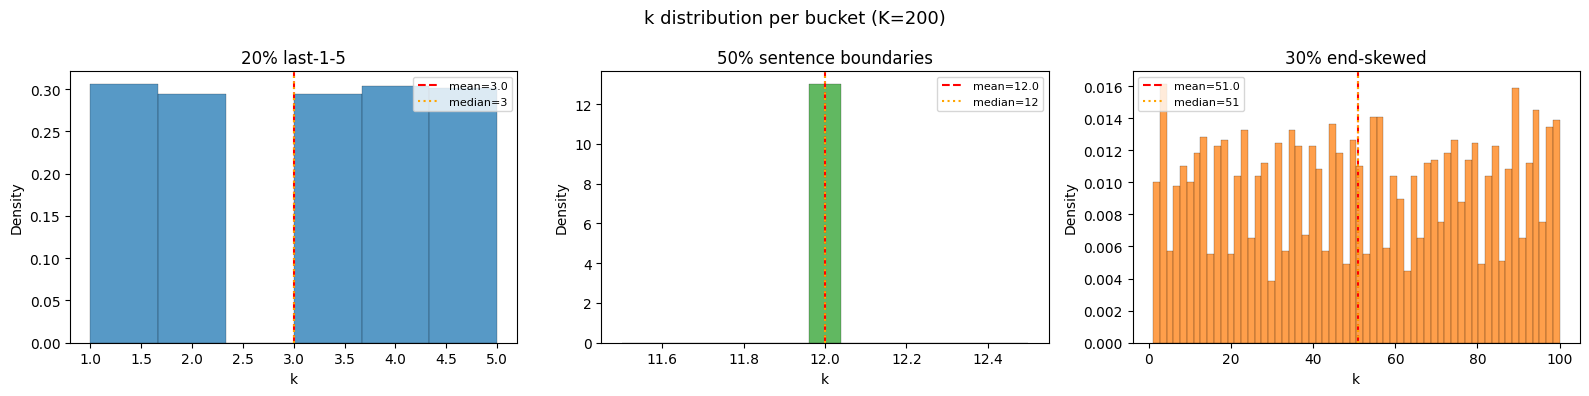

Overall mean k: 21.8, median: 12
  last_k: mean=3.0, median=3, p5=1, p95=5
  sentence: mean=12.0, median=12, p5=12, p95=12
  end_skewed: mean=51.0, median=51, p5=5, p95=96


In [4]:
n_samples = 10_000
rng = random.Random(42)
k_by_bucket = {"last_k": [], "sentence": [], "end_skewed": []}

for _ in range(n_samples):
    positions, bucket = sample_poisson_positions_tagged(base_positions, rng=rng, max_k=MAX_K, period_positions=period_positions)
    k_by_bucket.setdefault(bucket, []).append(len(positions))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
display_buckets = [("last_k", "20% last-1-5"), ("sentence", "50% sentence boundaries"), ("end_skewed", "30% end-skewed")]
for ax, (bucket, label) in zip(axes, display_buckets):
    ks = np.array(k_by_bucket.get(bucket, [0]))
    ax.hist(ks, bins=min(60, int(ks.max()) + 1), density=True, alpha=0.75,
            color=COLORS[bucket], edgecolor='black', linewidth=0.2)
    ax.axvline(ks.mean(), color='red', linestyle='--', label=f'mean={ks.mean():.1f}')
    ax.axvline(np.median(ks), color='orange', linestyle=':', label=f'median={np.median(ks):.0f}')
    ax.set_title(label); ax.set_xlabel('k'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

plt.suptitle(f'k distribution per bucket (K={K})', fontsize=13)
plt.tight_layout(); plt.show()

all_ks = np.array([k for ks in k_by_bucket.values() for k in ks])
print(f"Overall mean k: {all_ks.mean():.1f}, median: {np.median(all_ks):.0f}")
for bucket, ks in k_by_bucket.items():
    if not ks: continue
    ks = np.array(ks)
    print(f"  {bucket}: mean={ks.mean():.1f}, median={np.median(ks):.0f}, p5={np.percentile(ks,5):.0f}, p95={np.percentile(ks,95):.0f}")

## 4. Individual Draws — Event Plots (new scheme vs old stochastic)

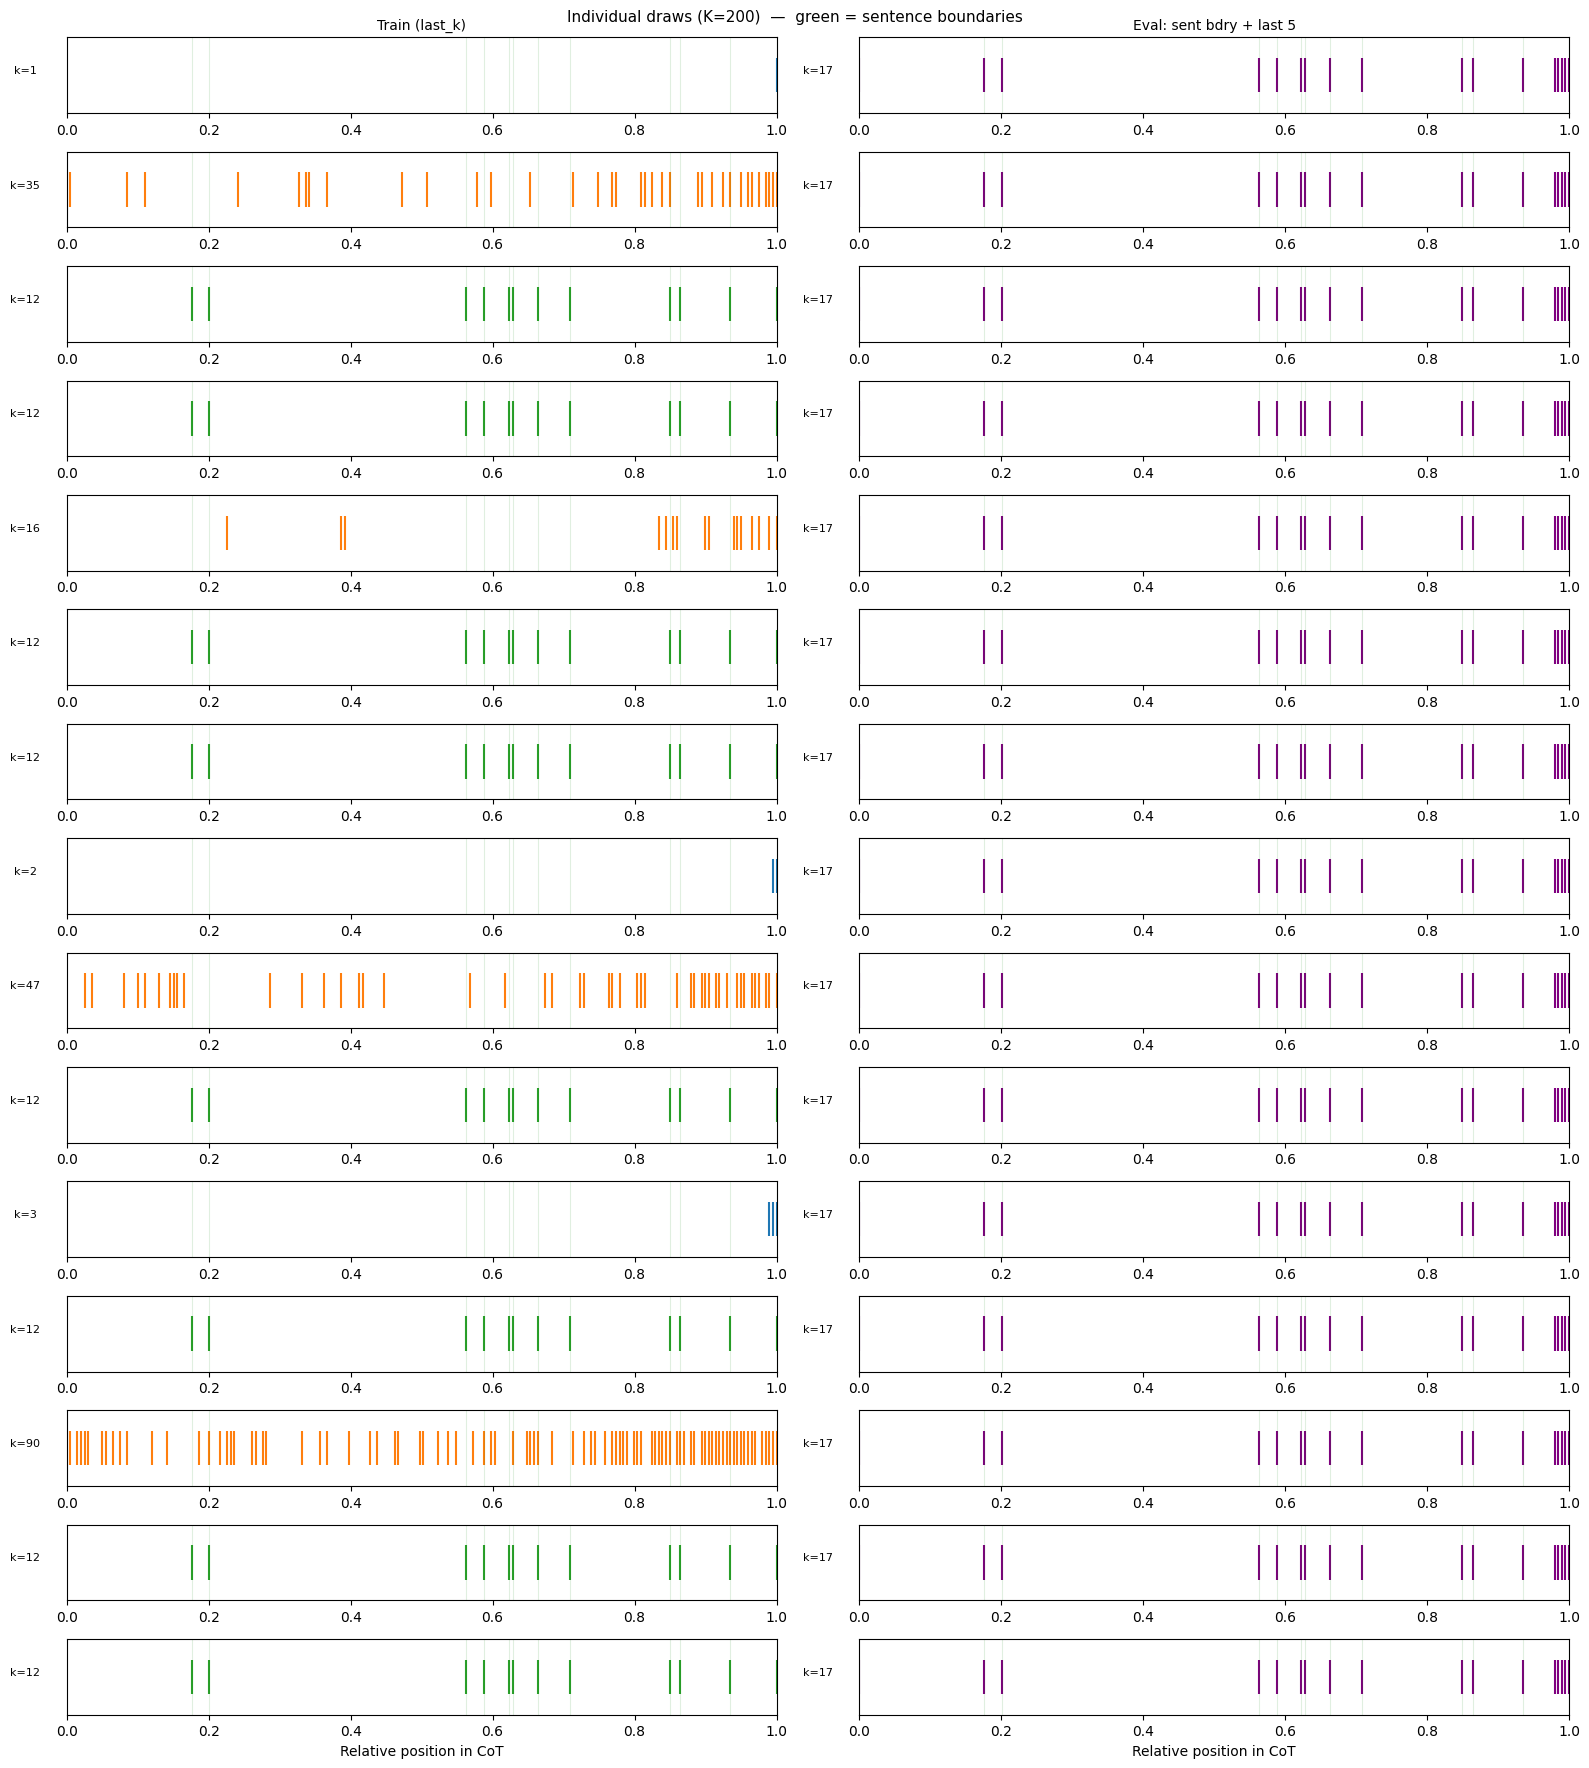

In [5]:
n_draws = 15
fig, axes = plt.subplots(n_draws, 2, figsize=(16, 1.2 * n_draws))

rng_train = random.Random(123)
eval_pos_rel = [p / base_positions[-1] for p in sentence_boundaries_plus_last5(base_positions, period_positions)]

for i in range(n_draws):
    train_pos, bucket = sample_poisson_positions_tagged(base_positions, rng=rng_train, max_k=MAX_K, period_positions=period_positions)
    train_rel = [p / base_positions[-1] for p in train_pos]

    for col, (name, rel, color) in enumerate([
        (f'Train ({bucket})', train_rel, COLORS.get(bucket, "C3")),
        ('Eval: sent bdry + last 5', eval_pos_rel, 'purple'),
    ]):
        axes[i, col].eventplot([rel], lineoffsets=0.5, linelengths=0.8, colors=color)
        axes[i, col].set_xlim(0, 1); axes[i, col].set_yticks([])
        axes[i, col].set_ylabel(f'k={len(rel)}', fontsize=8, rotation=0, labelpad=30)
        if i == 0: axes[i, col].set_title(name, fontsize=10)
        if i == n_draws - 1: axes[i, col].set_xlabel('Relative position in CoT')
        for sp in [p / base_positions[-1] for p in period_positions]:
            axes[i, col].axvline(sp, color='green', alpha=0.12, linewidth=0.8)

plt.suptitle(f'Individual draws (K={K})  —  green = sentence boundaries', fontsize=11)
plt.tight_layout(); plt.show()

## 5. Effect of Sentence Boundary Density

How does the number of sentence boundaries affect what the 30% bucket provides?

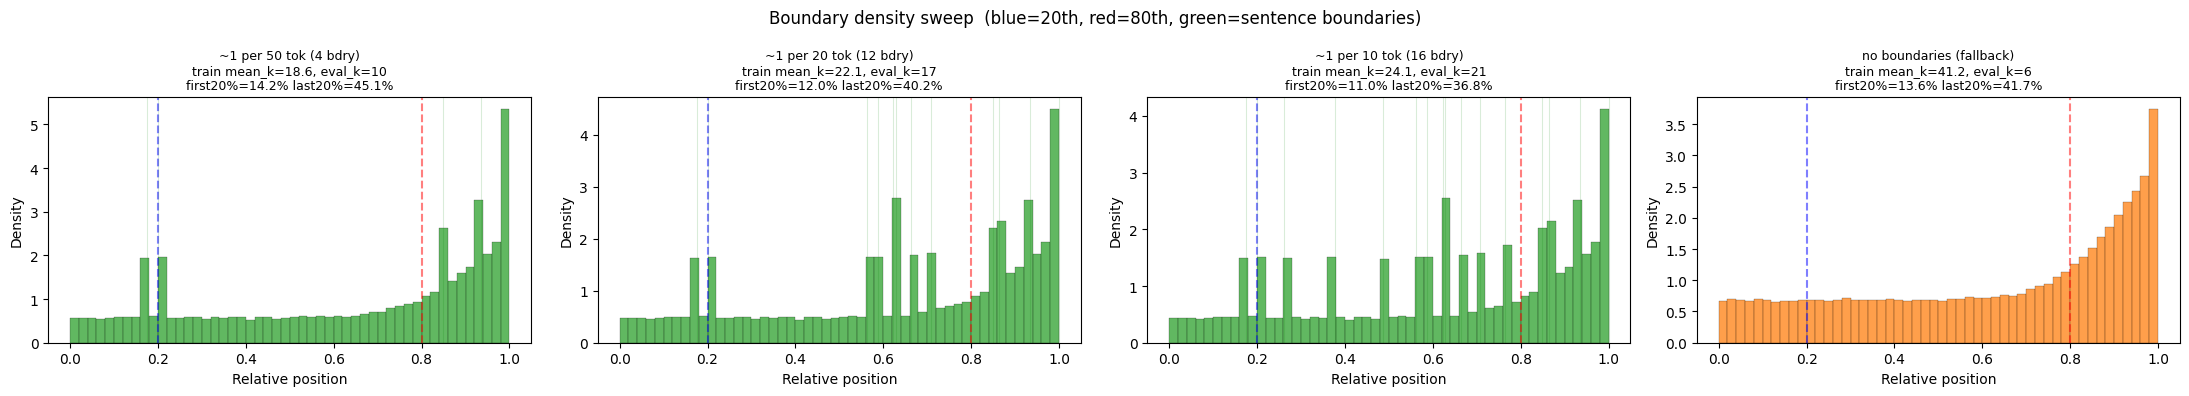

In [6]:
K = 200
base_positions = list(range(0, K * 5, 5))
n_samples = 3_000

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

for ax, period_rate in zip(axes, [0.02, 0.05, 0.1, 0.0]):
    rng_ref = random.Random(0)
    pp = sorted(p for p in base_positions if rng_ref.random() < period_rate) if period_rate > 0 else []
    title_extra = f'~1 per {int(1/period_rate/5)*5} tok ({len(pp)} bdry)' if pp else 'no boundaries (fallback)'

    rng = random.Random(42)
    rel_all, k_all = [], []
    for _ in range(n_samples):
        pos, _ = sample_poisson_positions_tagged(base_positions, rng=rng, max_k=MAX_K, period_positions=pp)
        rel_all.extend([p / base_positions[-1] for p in pos])
        k_all.append(len(pos))

    eval_k = len(sentence_boundaries_plus_last5(base_positions, pp))
    rel_all = np.array(rel_all)
    head, tail = (rel_all < 0.2).mean(), (rel_all > 0.8).mean()
    ax.hist(rel_all, bins=50, density=True, alpha=0.75, edgecolor='black', linewidth=0.2, color='C2' if pp else 'C1')
    ax.axvline(0.2, color='blue', linestyle='--', alpha=0.5)
    ax.axvline(0.8, color='red', linestyle='--', alpha=0.5)
    for sp in [p / base_positions[-1] for p in pp]:
        ax.axvline(sp, color='green', alpha=0.15, linewidth=0.8)
    ax.set_title(f'{title_extra}\ntrain mean_k={np.mean(k_all):.1f}, eval_k={eval_k}\nfirst20%={head:.1%} last20%={tail:.1%}', fontsize=9)
    ax.set_xlabel('Relative position'); ax.set_ylabel('Density')

plt.suptitle('Boundary density sweep  (blue=20th, red=80th, green=sentence boundaries)', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Comparison vs Old Scheme Across Sequence Lengths

In [7]:
print(f"{'K':>5} | {'mean_k':>8} | {'med_k':>6} | {'p5_k':>5} | {'p95_k':>6} | {'first20%':>9} | {'last20%':>8} | {'eval_k':>7}")
print('-' * 76)

for K in [30, 50, 100, 200, 400]:
    base = list(range(0, K * 5, 5))
    rng_ref = random.Random(0)
    pp = sorted(p for p in base if rng_ref.random() < 0.05)

    rng = random.Random(42)
    ks, first20, last20 = [], [], []
    for _ in range(10_000):
        s, _ = sample_poisson_positions_tagged(base, rng=rng, max_k=MAX_K, period_positions=pp)
        ks.append(len(s))
        rel = [p / base[-1] for p in s]
        first20.append(np.mean([r < 0.2 for r in rel]))
        last20.append(np.mean([r > 0.8 for r in rel]))

    ks = np.array(ks)
    eval_k = len(sentence_boundaries_plus_last5(base, pp))
    print(f"{K:>5} | {ks.mean():>8.1f} | {np.median(ks):>6.0f} | "
          f"{np.percentile(ks,5):>5.0f} | {np.percentile(ks,95):>6.0f} | "
          f"{np.mean(first20):>8.1%} | {np.mean(last20):>7.1%} | {eval_k:>7}")

    K |   mean_k |  med_k |  p5_k |  p95_k |  first20% |  last20% |  eval_k
----------------------------------------------------------------------------


   30 |     12.9 |     12 |     1 |     29 |    11.7% |   50.5% |       6
   50 |      9.7 |      3 |     2 |     42 |     4.5% |   64.7% |       8
  100 |     17.7 |      3 |     2 |     84 |     4.6% |   47.6% |       8
  200 |     21.8 |     12 |     2 |     85 |     7.9% |   50.3% |      17
  400 |     28.8 |     26 |     2 |     83 |     7.2% |   47.1% |      31
